# Tutorial: VICUNA NTN1 Ligand-Receptor Analysis - PyPI scCAMEL 0.47b0

This tutorial walks through a reproducible **NTN1-centered ligand-receptor analysis** using the published PyPI `scCAMEL` package.

**Datasets**

- Main dataset: `Couturier2020_DevGBM_Ref2023-05-27.h5ad`
- Cross-species reference dataset: `ZeiselDentateGyrus_Ref2023-05-27.h5ad`

**Tutorial goal**

We use **NTN1** as the ligand example, convert the Zeisel mouse gene symbols to human homologs, compute cluster-level VICUNA EScore matrices, score NTN1 ligand-receptor pairs across datasets, and visualize the results as tables, heatmaps, readable bar plots, a chord-style plot, and a Sankey/alluvial plot.

> **Note:** This version is intended as a user-facing tutorial for the published package. It imports the installed PyPI `scCAMEL` release instead of inserting a local `code/src` path.


In [1]:
# NOTE: This cell belongs to the tutorial step above. Run it after reading that section note.
import os
import sys
import pickle
import importlib.metadata as importlib_metadata
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display, Image as IPyImage
from scipy import sparse

VERSION_ROOT = Path("/mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260605")
PROJECT_ROOT = Path("/mnt/e/Loal_Temp/Vicuna_Example")
OUTPUT_DIR = VERSION_ROOT / "outputs" / "ntn1_couturier_zeisel_pypi047b0_tutorial"
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"

for path in [OUTPUT_DIR, FIG_DIR, TABLE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

import scCAMEL
from scCAMEL import CamelVicuna

SC_CAMEL_VERSION = importlib_metadata.version("scCAMEL")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 140

MAIN_PATH = PROJECT_ROOT / "Couturier2020_DevGBM_Ref2023-05-27.h5ad"
ZEISEL_PATH = PROJECT_ROOT / "ZeiselDentateGyrus_Ref2023-05-27.h5ad"
LR_PATH = PROJECT_ROOT / "Human_Final_ligand-receptor_Reference20250621.csv"
MOUSE2HUMAN_PATH = Path("/mnt/f/Dropbox/data/proj/PE_HYZ/PublicDataSet/Homologene_mouse2human_dict2.pickle")
CLUSTER_KEY = "Cluster"
LIGAND = "NTN1"

print("Using installed scCAMEL:", SC_CAMEL_VERSION)
print("scCAMEL import path:", Path(scCAMEL.__file__).parent)
print("Outputs:", OUTPUT_DIR)

Using installed scCAMEL: 0.47b0
scCAMEL import path: /home/huyiz/anaconda3/envs/py310/lib/python3.10/site-packages/scCAMEL
Outputs: /mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260605/outputs/ntn1_couturier_zeisel_pypi047b0_tutorial


## Step 1 - Helper Functions

> **Note:** These helper functions keep the tutorial self-contained. They handle sparse AnnData matrices, mouse-to-human gene conversion, EScore calculation, and saving outputs.

In [2]:
# NOTE: This cell belongs to the tutorial step above. Run it after reading that section note.
def sparse_status(adata):
    return "sparse" if sparse.issparse(adata.X) else "dense"


def load_mouse_to_human_mapping(path):
    with open(path, "rb") as handle:
        return pickle.load(handle, encoding="ASCII")


def detect_mouse_gene_fraction(adata, mapping):
    hits = sum(g in mapping for g in adata.var_names)
    return hits / max(adata.n_vars, 1), hits


def convert_mouse_to_human_adata(adata, mapping, min_fraction=0.2):
    # Map mouse var_names to human symbols and mean-collapse duplicate human genes.
    fraction, hits = detect_mouse_gene_fraction(adata, mapping)
    if fraction < min_fraction:
        result = adata.copy()
        result.var_names_make_unique()
        return result, {
            "converted": False,
            "mapping_hits": hits,
            "mapping_fraction": fraction,
            "genes_before": adata.n_vars,
            "genes_after": result.n_vars,
        }

    mapped = pd.Series(adata.var_names, index=adata.var_names).map(mapping)
    keep = mapped.notna()
    kept_names = mapped.loc[keep].astype(str)
    unique_genes = pd.Index(pd.unique(kept_names))
    codes = pd.Categorical(kept_names, categories=unique_genes).codes
    counts = np.bincount(codes)

    x = adata[:, keep.values].X
    if not sparse.issparse(x):
        x = sparse.csr_matrix(x)
    else:
        x = x.tocsr()

    # cells x kept_mouse_genes times kept_mouse_genes x unique_human_genes
    # weights are 1 / duplicate_count so duplicate mouse genes are mean-collapsed.
    rows = np.arange(len(codes))
    weights = 1.0 / counts[codes]
    reducer = sparse.csr_matrix(
        (weights, (rows, codes)),
        shape=(len(codes), len(unique_genes)),
    )
    x_human = x @ reducer

    result = ad.AnnData(
        X=x_human.tocsr(),
        obs=adata.obs.copy(),
        var=pd.DataFrame(index=unique_genes),
        uns=adata.uns.copy(),
    )
    result.obs_names = adata.obs_names.copy()
    result.var_names_make_unique()
    return result, {
        "converted": True,
        "mapping_hits": hits,
        "mapping_fraction": fraction,
        "genes_before": adata.n_vars,
        "genes_after": result.n_vars,
    }


def compute_escore_sparse(adata, cluster_key="Cluster", scale=1000.0, pseudo_expr=0.01, pseudo_count=0.1):
    # Sparse-friendly version of the VICUNA cluster x gene EScore logic.
    if cluster_key not in adata.obs:
        raise KeyError(f"{cluster_key!r} not found in adata.obs")

    x = adata.X
    if sparse.issparse(x):
        x = x.tocsr()
    else:
        x = sparse.csr_matrix(np.asarray(x))

    clusters = pd.Categorical(adata.obs[cluster_key].astype(str))
    cluster_names = pd.Index(clusters.categories.astype(str))
    codes = clusters.codes
    valid = codes >= 0
    if not np.all(valid):
        x = x[valid]
        codes = codes[valid]

    n_cells = x.shape[0]
    n_clusters = len(cluster_names)
    indicator = sparse.csr_matrix(
        (np.ones(n_cells), (np.arange(n_cells), codes)),
        shape=(n_cells, n_clusters),
    )
    cluster_counts = np.asarray(indicator.sum(axis=0)).ravel()
    cluster_counts[cluster_counts == 0] = 1

    cluster_sum = indicator.T @ x
    cluster_mean = cluster_sum.multiply(1.0 / cluster_counts[:, None]).toarray()

    gene_mean = np.asarray(x.mean(axis=0)).ravel()
    total_nz = np.asarray(x.getnnz(axis=0)).ravel()
    nz = x.copy()
    nz.data = np.ones_like(nz.data)
    grp_nz = (indicator.T @ nz).toarray()
    rest_nz = total_nz[None, :] - grp_nz

    ratio_nz = ((grp_nz + pseudo_count) / (rest_nz + pseudo_count) / cluster_counts[:, None]) * scale
    fold = np.sqrt((cluster_mean + pseudo_expr) / (gene_mean[None, :] + pseudo_expr))
    escore = fold * ratio_nz
    escore[~np.isfinite(escore)] = 0

    return pd.DataFrame(escore.T, index=adata.var_names.astype(str), columns=cluster_names)


def summarize_dataset(name, adata, conversion_info):
    return {
        "dataset": name,
        "cells": adata.n_obs,
        "genes": adata.n_vars,
        "matrix": sparse_status(adata),
        "cluster_key": CLUSTER_KEY,
        "n_clusters": adata.obs[CLUSTER_KEY].nunique(),
        "converted_mouse_to_human": conversion_info.get("converted", False),
        "mapping_hits": conversion_info.get("mapping_hits", np.nan),
        "mapping_fraction": conversion_info.get("mapping_fraction", np.nan),
        "genes_before_conversion": conversion_info.get("genes_before", adata.n_vars),
        "genes_after_conversion": conversion_info.get("genes_after", adata.n_vars),
    }


def save_table(df, name):
    path = TABLE_DIR / name
    df.to_csv(path)
    print("Saved table:", path)
    return path


def save_current_fig(name):
    path = FIG_DIR / name
    plt.savefig(path, bbox_inches="tight")
    print("Saved figure:", path)
    display(IPyImage(filename=str(path)))
    return path


def _short_dataset_name(name):
    if "Couturier" in name:
        return "GBM"
    if "Zeisel" in name:
        return "DG"
    return str(name)


def _short_direction_name(name):
    if "Couturier" in str(name) and "Zeisel" in str(name):
        return "GBM -> DG" if str(name).startswith("Couturier") else "DG -> GBM"
    return str(name)


def _node_label(dataset, cluster):
    return f"{_short_dataset_name(dataset)}:{cluster}"


def draw_chord_plot(edge_df, filename, top_n=18, title="Chord-style NTN1 communication plot"):
    # NOTE: This static chord-style plot reserves external space for title, legend, and labels.
    from matplotlib.path import Path
    from matplotlib.patches import PathPatch

    edges = edge_df.loc[edge_df["score"] > 0].head(top_n).copy()
    if "source_dataset" not in edges.columns or "target_dataset" not in edges.columns:
        direction_parts = edges["direction"].astype(str).str.split(" -> ", n=1, expand=True)
        edges["source_dataset"] = direction_parts[0]
        edges["target_dataset"] = direction_parts[1]
    edges["source_node"] = edges.apply(lambda r: _node_label(r["source_dataset"], r["source_cluster"]), axis=1)
    edges["target_node"] = edges.apply(lambda r: _node_label(r["target_dataset"], r["target_cluster"]), axis=1)
    edges["direction_short"] = edges["direction"].map(_short_direction_name)
    edges = (
        edges.groupby(["direction", "direction_short", "source_node", "target_node"], observed=False)["score"]
        .sum()
        .reset_index()
        .sort_values("score", ascending=False)
        .head(top_n)
    )

    node_order = pd.concat([edges["source_node"], edges["target_node"]], ignore_index=True)
    nodes = pd.Index(pd.unique(node_order))
    if len(nodes) == 0:
        raise ValueError("No positive edges are available for the chord-style plot.")

    angles = np.linspace(np.pi / 2, np.pi / 2 - 2 * np.pi, len(nodes), endpoint=False)
    node_pos = {node: np.array([np.cos(angle), np.sin(angle)]) for node, angle in zip(nodes, angles)}

    fig, ax = plt.subplots(figsize=(11.5, 11.5))
    fig.subplots_adjust(left=0.03, right=0.97, top=0.88, bottom=0.10)
    max_score = edges["score"].max()
    direction_palette = {
        "GBM -> DG": "#3478b7",
        "DG -> GBM": "#c44e52",
    }

    for _, row in edges.iterrows():
        start = node_pos[row["source_node"]]
        end = node_pos[row["target_node"]]
        verts = [start, start * 0.32, end * 0.32, end]
        path = Path(verts, [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4])
        lw = 0.9 + 7.0 * (row["score"] / max_score)
        color = direction_palette.get(row["direction_short"], "#777777")
        ax.add_patch(PathPatch(path, facecolor="none", edgecolor=color, lw=lw, alpha=0.42, capstyle="round"))

    node_strength = (
        pd.concat([
            edges[["source_node", "score"]].rename(columns={"source_node": "node"}),
            edges[["target_node", "score"]].rename(columns={"target_node": "node"}),
        ])
        .groupby("node", observed=False)["score"].sum()
    )

    for node in nodes:
        x, y = node_pos[node]
        size = 180 + 760 * node_strength.get(node, 0) / max(node_strength.max(), 1e-9)
        color = "#4c72b0" if node.startswith("GBM:") else "#dd8452"
        ax.scatter([x], [y], s=size, c=color, edgecolor="white", linewidth=1.3, zorder=3)

        label_radius = 1.25
        tx, ty = x * label_radius, y * label_radius
        ha = "left" if x > 0.20 else "right" if x < -0.20 else "center"
        va = "bottom" if y > 0.82 else "top" if y < -0.82 else "center"
        if abs(x) < 0.20 and y > 0:
            ty += 0.06
        elif abs(x) < 0.20 and y < 0:
            ty -= 0.06
        ax.text(
            tx,
            ty,
            node,
            ha=ha,
            va=va,
            fontsize=9.5,
            color="#222222",
            bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.82, "pad": 1.5},
            zorder=4,
        )

    legend_handles = [
        plt.Line2D([0], [0], color="#3478b7", lw=5, alpha=0.65, label="GBM NTN1 ligand -> DG receptor"),
        plt.Line2D([0], [0], color="#c44e52", lw=5, alpha=0.65, label="DG NTN1 ligand -> GBM receptor"),
    ]
    ax.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.04),
        ncol=2,
        frameon=False,
        fontsize=10,
    )
    ax.set_title(title, pad=28, fontsize=15)
    ax.set_aspect("equal")
    ax.set_xlim(-1.55, 1.55)
    ax.set_ylim(-1.50, 1.50)
    ax.axis("off")
    path = FIG_DIR / filename
    plt.savefig(path, bbox_inches="tight")
    print("Saved figure:", path)
    display(IPyImage(filename=str(path)))
    return edges, path


def draw_sankey_alluvial(top_df, filename, top_n=18, title="Top NTN1 paths: source cluster -> receptor -> target cluster"):
    # NOTE: This static Sankey/alluvial plot avoids browser-specific rendering and remains visible in saved notebooks.
    from matplotlib.path import Path
    from matplotlib.patches import PathPatch

    flows = top_df.loc[top_df["score"] > 0].head(top_n).copy()
    flows["source_node"] = flows.apply(lambda r: _node_label(r["source_dataset"], r["source_cluster"]), axis=1)
    flows["target_node"] = flows.apply(lambda r: _node_label(r["target_dataset"], r["target_cluster"]), axis=1)
    flows["receptor_node"] = flows["receptor"].astype(str)
    flows["direction_short"] = flows["direction"].map(_short_direction_name)

    source_totals = flows.groupby("source_node", observed=False)["score"].sum().sort_values(ascending=False)
    receptor_totals = flows.groupby("receptor_node", observed=False)["score"].sum().sort_values(ascending=False)
    target_totals = flows.groupby("target_node", observed=False)["score"].sum().sort_values(ascending=False)

    def positions(labels):
        if len(labels) == 1:
            return {labels[0]: 0.5}
        ys = np.linspace(0.91, 0.09, len(labels))
        return dict(zip(labels, ys))

    src_pos = positions(source_totals.index.tolist())
    rec_pos = positions(receptor_totals.index.tolist())
    tgt_pos = positions(target_totals.index.tolist())

    fig, ax = plt.subplots(figsize=(13, max(6.5, 0.42 * max(len(src_pos), len(rec_pos), len(tgt_pos)))))
    fig.subplots_adjust(left=0.11, right=0.89, top=0.84, bottom=0.08)
    max_score = flows["score"].max()
    direction_palette = {
        "GBM -> DG": "#3478b7",
        "DG -> GBM": "#c44e52",
    }

    def ribbon(x0, y0, x1, y1, score, color, alpha):
        width = 0.006 + 0.035 * (score / max_score)
        verts = [
            (x0, y0 + width), ((x0 + x1) / 2, y0 + width), ((x0 + x1) / 2, y1 + width), (x1, y1 + width),
            (x1, y1 - width), ((x0 + x1) / 2, y1 - width), ((x0 + x1) / 2, y0 - width), (x0, y0 - width),
            (x0, y0 + width),
        ]
        codes = [
            Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4,
            Path.LINETO, Path.CURVE4, Path.CURVE4, Path.CURVE4,
            Path.CLOSEPOLY,
        ]
        ax.add_patch(PathPatch(Path(verts, codes), facecolor=color, edgecolor="none", alpha=alpha))

    for _, row in flows.iterrows():
        color = direction_palette.get(row["direction_short"], "#777777")
        ribbon(0.14, src_pos[row["source_node"]], 0.50, rec_pos[row["receptor_node"]], row["score"], color, 0.34)
        ribbon(0.50, rec_pos[row["receptor_node"]], 0.86, tgt_pos[row["target_node"]], row["score"], color, 0.22)

    def draw_nodes(x, pos, totals, title_text):
        ax.text(x, 1.02, title_text, ha="center", va="bottom", fontsize=11, weight="bold")
        total_max = max(totals.max(), 1e-9)
        for label, y in pos.items():
            height = 0.025 + 0.06 * totals.loc[label] / total_max
            rect_color = "#4c72b0" if str(label).startswith("GBM:") else "#dd8452" if str(label).startswith("DG:") else "#55a868"
            ax.add_patch(plt.Rectangle((x - 0.014, y - height / 2), 0.028, height, color=rect_color, ec="white", lw=0.8, zorder=3))
            ha = "right" if x < 0.2 else "left" if x > 0.8 else "center"
            tx = x - 0.030 if x < 0.2 else x + 0.030 if x > 0.8 else x
            ax.text(tx, y, label, ha=ha, va="center", fontsize=9)

    draw_nodes(0.14, src_pos, source_totals, "Source cluster")
    draw_nodes(0.50, rec_pos, receptor_totals, "NTN1 receptor")
    draw_nodes(0.86, tgt_pos, target_totals, "Target cluster")

    legend_handles = [
        plt.Line2D([0], [0], color="#3478b7", lw=5, alpha=0.65, label="GBM -> DG"),
        plt.Line2D([0], [0], color="#c44e52", lw=5, alpha=0.65, label="DG -> GBM"),
    ]
    ax.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, 1.10), ncol=2, frameon=False)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.08)
    ax.axis("off")
    ax.set_title(title, y=1.16, fontsize=15)
    path = FIG_DIR / filename
    plt.savefig(path, bbox_inches="tight")
    print("Saved figure:", path)
    display(IPyImage(filename=str(path)))
    return flows, path


## Step 2 - Load Datasets And Convert Zeisel Mouse Genes

> **Note:** The Couturier GBM dataset already uses human-like gene symbols. The Zeisel dentate gyrus dataset is mouse, so we map mouse genes to human homolog symbols and mean-collapse duplicate homologs.

In [3]:
# NOTE: This cell belongs to the tutorial step above. Run it after reading that section note.
mouse2human = load_mouse_to_human_mapping(MOUSE2HUMAN_PATH)

main = ad.read_h5ad(MAIN_PATH)
zeisel_raw = ad.read_h5ad(ZEISEL_PATH)

main.var_names_make_unique()
zeisel, zeisel_conversion = convert_mouse_to_human_adata(zeisel_raw, mouse2human)
main_conversion = {
    "converted": False,
    "mapping_hits": detect_mouse_gene_fraction(main, mouse2human)[1],
    "mapping_fraction": detect_mouse_gene_fraction(main, mouse2human)[0],
    "genes_before": main.n_vars,
    "genes_after": main.n_vars,
}

dataset_summary = pd.DataFrame([
    summarize_dataset("Couturier2020_DevGBM", main, main_conversion),
    summarize_dataset("ZeiselDentateGyrus_humanized", zeisel, zeisel_conversion),
])
display(dataset_summary)
save_table(dataset_summary, "dataset_summary.csv")

cluster_counts = pd.concat(
    {
        "Couturier2020_DevGBM": main.obs[CLUSTER_KEY].astype(str).value_counts(),
        "ZeiselDentateGyrus_humanized": zeisel.obs[CLUSTER_KEY].astype(str).value_counts(),
    },
    axis=1,
).fillna(0).astype(int)
display(cluster_counts)
save_table(cluster_counts, "cluster_counts.csv")

,dataset,cells,genes,matrix,cluster_key,n_clusters,converted_mouse_to_human,mapping_hits,mapping_fraction,genes_before_conversion,genes_after_conversion
0,Couturier2020_DevGBM,18475,33660,sparse,Cluster,6,False,15,0.000446,33660,33660
1,ZeiselDentateGyrus_humanized,5454,12516,sparse,Cluster,15,True,12516,0.860502,14545,12516


Saved table: /mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260605/outputs/ntn1_couturier_zeisel_pypi047b0_tutorial/tables/dataset_summary.csv


,Couturier2020_DevGBM,ZeiselDentateGyrus_humanized
Cluster,,
Progenitor,5040,0
Unassigned,5026,0
Mesenchymal,2824,0
Oligo,2589,0
Astro,1883,0
Neuronal,1113,0
Granule,0,3045
Neuroblast,0,874
Astrocytes,0,335


Saved table: /mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260605/outputs/ntn1_couturier_zeisel_pypi047b0_tutorial/tables/cluster_counts.csv


PosixPath('/mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260605/outputs/ntn1_couturier_zeisel_pypi047b0_tutorial/tables/cluster_counts.csv')

## Step 3 - Select NTN1 Ligand-Receptor Pairs

> **Note:** The ligand-receptor catalogue contains many pairs. Here we keep only rows where `ligand_symbol == NTN1`, then check which receptors exist in each dataset after conversion.

In [4]:
# NOTE: This cell belongs to the tutorial step above. Run it after reading that section note.
lr_all = pd.read_csv(LR_PATH)
lr_all = CamelVicuna.normalize_ligand_receptor_table(lr_all)
ntn1_pairs = lr_all.loc[lr_all["ligand_symbol"].str.upper() == LIGAND].copy()
ntn1_pairs["receptor_in_couturier"] = ntn1_pairs["receptor_symbol"].isin(main.var_names)
ntn1_pairs["receptor_in_zeisel_humanized"] = ntn1_pairs["receptor_symbol"].isin(zeisel.var_names)
ntn1_pairs["ligand_in_couturier"] = LIGAND in set(main.var_names)
ntn1_pairs["ligand_in_zeisel_humanized"] = LIGAND in set(zeisel.var_names)

display(ntn1_pairs)
save_table(ntn1_pairs, "ntn1_ligand_receptor_pairs.csv")

print(f"NTN1 in Couturier genes: {LIGAND in set(main.var_names)}")
print(f"NTN1 in humanized Zeisel genes: {LIGAND in set(zeisel.var_names)}")
print("NTN1 receptors available in Zeisel:", int(ntn1_pairs["receptor_in_zeisel_humanized"].sum()))
print("NTN1 receptors available in Couturier:", int(ntn1_pairs["receptor_in_couturier"].sum()))

,PPI,ligand_symbol,receptor_symbol,receptor_in_couturier,receptor_in_zeisel_humanized,ligand_in_couturier,ligand_in_zeisel_humanized
NTN1-DCC,NTN1_DCC,NTN1,DCC,True,True,True,True
NTN1-UNC5C,NTN1_UNC5C,NTN1,UNC5C,True,True,True,True
NTN1-NEO1,NTN1_NEO1,NTN1,NEO1,True,True,True,True
NTN1-ITGB4,NTN1_ITGB4,NTN1,ITGB4,True,True,True,True
NTN1-ITGA6,NTN1_ITGA6,NTN1,ITGA6,True,True,True,True
NTN1-ACVR1B,NTN1_ACVR1B,NTN1,ACVR1B,True,True,True,True
NTN1-TGFBR1,NTN1_TGFBR1,NTN1,TGFBR1,True,True,True,True
NTN1-NOTCH1,NTN1_NOTCH1,NTN1,NOTCH1,True,True,True,True
NTN1-NOTCH2,NTN1_NOTCH2,NTN1,NOTCH2,True,True,True,True
NTN1-PTCH1,NTN1_PTCH1,NTN1,PTCH1,True,True,True,True


Saved table: /mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260605/outputs/ntn1_couturier_zeisel_pypi047b0_tutorial/tables/ntn1_ligand_receptor_pairs.csv
NTN1 in Couturier genes: True
NTN1 in humanized Zeisel genes: True
NTN1 receptors available in Zeisel: 14
NTN1 receptors available in Couturier: 15


## Step 4 - Compute Cluster-Level EScore Matrices

> **Note:** EScore summarizes how enriched each gene is in each cluster. The implementation below is sparse-aware so large single-cell matrices do not need to be densified.

In [5]:
# NOTE: This cell belongs to the tutorial step above. Run it after reading that section note.
escore_main = compute_escore_sparse(main, CLUSTER_KEY)
escore_zeisel = compute_escore_sparse(zeisel, CLUSTER_KEY)

print("Couturier EScore:", escore_main.shape)
print("Zeisel humanized EScore:", escore_zeisel.shape)

escore_main.to_csv(TABLE_DIR / "couturier_escore_genes_by_cluster.csv")
escore_zeisel.to_csv(TABLE_DIR / "zeisel_humanized_escore_genes_by_cluster.csv")

ntn1_escore = pd.concat(
    {
        "Couturier2020_DevGBM": escore_main.loc[LIGAND] if LIGAND in escore_main.index else pd.Series(dtype=float),
        "ZeiselDentateGyrus_humanized": escore_zeisel.loc[LIGAND] if LIGAND in escore_zeisel.index else pd.Series(dtype=float),
    },
    axis=1,
).fillna(0)
display(ntn1_escore)
save_table(ntn1_escore, "ntn1_ligand_escore_by_cluster.csv")

Couturier EScore: (33660, 6)
Zeisel humanized EScore: (12516, 15)


,Couturier2020_DevGBM,ZeiselDentateGyrus_humanized
Astro,0.129475,0.000000
Mesenchymal,0.165878,0.000000
Neuronal,0.005197,0.000000
Oligo,0.057008,0.000000
Progenitor,0.039397,0.000000
Unassigned,0.058557,0.000000
Astrocytes,0.000000,0.136631
Cajal-Retzius,0.000000,0.017685
Cck-Tox,0.000000,0.060915
Endo,0.000000,1.617338


Saved table: /mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260605/outputs/ntn1_couturier_zeisel_pypi047b0_tutorial/tables/ntn1_ligand_escore_by_cluster.csv


PosixPath('/mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260605/outputs/ntn1_couturier_zeisel_pypi047b0_tutorial/tables/ntn1_ligand_escore_by_cluster.csv')

## Step 5 - Score Cross-Dataset NTN1 Interactions

> **Note:** We score both directions: Couturier clusters as NTN1 ligand senders to Zeisel receptor clusters, and Zeisel clusters as NTN1 ligand senders to Couturier receptor clusters.

In [6]:
# NOTE: This cell belongs to the tutorial step above. Run it after reading that section note.
main_clusters = list(escore_main.columns)
zeisel_clusters = list(escore_zeisel.columns)

main_to_zeisel = CamelVicuna.lr_score_cross_datasets(
    main,
    escore_main,
    zeisel,
    escore_zeisel,
    ntn1_pairs,
    clusters_L=main_clusters,
    clusters_R=zeisel_clusters,
    use_var_filter=False,
    include_all_pairs=True,
    missing_value=0.0,
    verbose=False,
)

zeisel_to_main = CamelVicuna.lr_score_cross_datasets(
    zeisel,
    escore_zeisel,
    main,
    escore_main,
    ntn1_pairs,
    clusters_L=zeisel_clusters,
    clusters_R=main_clusters,
    use_var_filter=False,
    include_all_pairs=True,
    missing_value=0.0,
    verbose=False,
)

display(main_to_zeisel.head())
display(zeisel_to_main.head())
save_table(main_to_zeisel, "ntn1_scores_couturier_ligand_to_zeisel_receptor.csv")
save_table(zeisel_to_main, "ntn1_scores_zeisel_ligand_to_couturier_receptor.csv")

,Astro(lig)-Astrocytes(rec),Astro(lig)-Cajal-Retzius(rec),Astro(lig)-Cck-Tox(rec),Astro(lig)-Endo(rec),Astro(lig)-GABA(rec),Astro(lig)-Granule(rec),Astro(lig)-Microglia(rec),Astro(lig)-Mossy(rec),Astro(lig)-NFOL(rec),Astro(lig)-Neuroblast(rec),...,Unassigned(lig)-Granule(rec),Unassigned(lig)-Microglia(rec),Unassigned(lig)-Mossy(rec),Unassigned(lig)-NFOL(rec),Unassigned(lig)-Neuroblast(rec),Unassigned(lig)-OLIG(rec),Unassigned(lig)-OPC(rec),Unassigned(lig)-PVM(rec),Unassigned(lig)-Peri/VLMC(rec),Unassigned(lig)-nIPC/Rgl(rec)
NTN1-DCC,0.002050,0.009336,0.002013,0.000329,0.010580,0.056994,0.000322,0.165493,0.001553,0.075037,...,0.025777,0.000145,0.074847,0.000702,0.033937,0.005194,0.015954,0.001366,0.000417,0.000097
NTN1-UNC5C,0.003546,0.000295,0.062440,0.000166,0.883177,0.026145,0.000162,1.249618,0.043046,0.003197,...,0.011825,0.000073,0.565162,0.019468,0.001446,0.016173,0.013924,0.000688,0.000210,0.001391
NTN1-NEO1,0.033468,0.012949,0.012244,0.016123,0.059283,0.028778,0.000445,0.237931,0.018831,0.052915,...,0.013015,0.000201,0.107609,0.008517,0.023932,0.040132,0.007256,0.003836,0.003188,0.005261
NTN1-ITGB4,0.001237,0.004455,0.015345,0.002511,0.004185,0.007059,0.002452,0.045570,0.011838,0.000474,...,0.003192,0.001109,0.020610,0.005354,0.000214,13.406593,0.002839,0.010410,0.003176,0.000741
NTN1-ITGA6,0.282606,0.000261,0.000899,0.322254,0.084249,0.009304,0.055984,0.025770,0.015055,0.021366,...,0.004208,0.025320,0.011655,0.006809,0.009663,0.000139,0.000166,0.044992,0.023919,0.012146


,Astrocytes(lig)-Astro(rec),Astrocytes(lig)-Mesenchymal(rec),Astrocytes(lig)-Neuronal(rec),Astrocytes(lig)-Oligo(rec),Astrocytes(lig)-Progenitor(rec),Astrocytes(lig)-Unassigned(rec),Cajal-Retzius(lig)-Astro(rec),Cajal-Retzius(lig)-Mesenchymal(rec),Cajal-Retzius(lig)-Neuronal(rec),Cajal-Retzius(lig)-Oligo(rec),...,Peri/VLMC(lig)-Neuronal(rec),Peri/VLMC(lig)-Oligo(rec),Peri/VLMC(lig)-Progenitor(rec),Peri/VLMC(lig)-Unassigned(rec),nIPC/Rgl(lig)-Astro(rec),nIPC/Rgl(lig)-Mesenchymal(rec),nIPC/Rgl(lig)-Neuronal(rec),nIPC/Rgl(lig)-Oligo(rec),nIPC/Rgl(lig)-Progenitor(rec),nIPC/Rgl(lig)-Unassigned(rec)
NTN1-DCC,0.005438,0.010076,0.028388,0.006397,0.008431,0.009167,0.000704,0.001304,0.003674,0.000828,...,0.314630,0.070899,0.093446,0.101594,0.042564,0.078869,0.222213,0.050074,0.065998,0.071753
NTN1-UNC5C,0.007830,0.008013,0.006613,0.000847,0.020934,0.010461,0.001014,0.001037,0.000856,0.000110,...,0.073292,0.009390,0.232016,0.115941,0.061292,0.062724,0.051764,0.006632,0.163865,0.081885
NTN1-NEO1,0.012324,0.015459,0.003156,0.005781,0.009758,0.008433,0.001595,0.002001,0.000409,0.000748,...,0.034983,0.064071,0.108153,0.093464,0.096466,0.121005,0.024707,0.045251,0.076385,0.066011
NTN1-ITGB4,0.030540,0.032069,0.000444,0.001563,0.003852,0.008558,0.003953,0.004151,0.000057,0.000202,...,0.004919,0.017322,0.042687,0.094851,0.239052,0.251023,0.003474,0.012234,0.030149,0.066990
NTN1-ITGA6,0.025086,0.007059,0.005380,0.003924,0.009840,0.009722,0.003247,0.000914,0.000696,0.000508,...,0.059626,0.043494,0.109057,0.107750,0.196362,0.055254,0.042112,0.030718,0.077023,0.076101


Saved table: /mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260605/outputs/ntn1_couturier_zeisel_pypi047b0_tutorial/tables/ntn1_scores_couturier_ligand_to_zeisel_receptor.csv
Saved table: /mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260605/outputs/ntn1_couturier_zeisel_pypi047b0_tutorial/tables/ntn1_scores_zeisel_ligand_to_couturier_receptor.csv


PosixPath('/mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260605/outputs/ntn1_couturier_zeisel_pypi047b0_tutorial/tables/ntn1_scores_zeisel_ligand_to_couturier_receptor.csv')

## Step 6 - Build Long Tables For Ranking And Plotting

> **Note:** The wide score matrices are convenient for storage, but long-form tables are easier for ranking, plotting, and exporting into downstream tools.

In [7]:
# NOTE: This cell belongs to the tutorial step above. Run it after reading that section note.
def lr_matrix_to_long(score_df, source_dataset, target_dataset):
    rows = []
    for pair, row in score_df.iterrows():
        ligand, receptor = str(pair).split("-", 1)
        for col, score in row.items():
            source_cluster, target_cluster = str(col).split("(lig)-")
            target_cluster = target_cluster.replace("(rec)", "")
            rows.append({
                "direction": f"{source_dataset} -> {target_dataset}",
                "source_dataset": source_dataset,
                "target_dataset": target_dataset,
                "source_cluster": source_cluster,
                "target_cluster": target_cluster,
                "pair": pair,
                "ligand": ligand,
                "receptor": receptor,
                "score": float(score),
            })
    return pd.DataFrame(rows)


long_scores = pd.concat(
    [
        lr_matrix_to_long(main_to_zeisel, "Couturier2020_DevGBM", "ZeiselDentateGyrus_humanized"),
        lr_matrix_to_long(zeisel_to_main, "ZeiselDentateGyrus_humanized", "Couturier2020_DevGBM"),
    ],
    ignore_index=True,
)
long_scores = long_scores.sort_values("score", ascending=False)
top_interactions = long_scores.loc[long_scores["score"] > 0].head(50)

display(top_interactions)
save_table(long_scores, "ntn1_all_directional_scores_long.csv")
save_table(top_interactions, "ntn1_top50_directional_scores.csv")

cluster_pair_summary = (
    long_scores.groupby(["direction", "source_cluster", "target_cluster"], observed=False)["score"]
    .sum()
    .reset_index()
    .sort_values("score", ascending=False)
)
display(cluster_pair_summary.head(30))
save_table(cluster_pair_summary, "ntn1_cluster_pair_score_summary.csv")

,direction,source_dataset,target_dataset,source_cluster,target_cluster,pair,ligand,receptor,score
295,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,Couturier2020_DevGBM,ZeiselDentateGyrus_humanized,Mesenchymal,OLIG,NTN1-ITGB4,NTN1,ITGB4,37.977537
280,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,Couturier2020_DevGBM,ZeiselDentateGyrus_humanized,Astro,OLIG,NTN1-ITGB4,NTN1,ITGB4,29.643023
355,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,Couturier2020_DevGBM,ZeiselDentateGyrus_humanized,Unassigned,OLIG,NTN1-ITGB4,NTN1,ITGB4,13.406593
325,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,Couturier2020_DevGBM,ZeiselDentateGyrus_humanized,Oligo,OLIG,NTN1-ITGB4,NTN1,ITGB4,13.051785
340,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,Couturier2020_DevGBM,ZeiselDentateGyrus_humanized,Progenitor,OLIG,NTN1-ITGB4,NTN1,ITGB4,9.019840
2407,ZeiselDentateGyrus_humanized -> Couturier2020_...,ZeiselDentateGyrus_humanized,Couturier2020_DevGBM,OPC,Mesenchymal,NTN1-ACVR1C,NTN1,ACVR1C,8.698030
1687,ZeiselDentateGyrus_humanized -> Couturier2020_...,ZeiselDentateGyrus_humanized,Couturier2020_DevGBM,OPC,Mesenchymal,NTN1-ITGB4,NTN1,ITGB4,4.295583
1188,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,Couturier2020_DevGBM,ZeiselDentateGyrus_humanized,Mesenchymal,Endo,NTN1-NOTCH3,NTN1,NOTCH3,4.228401
1686,ZeiselDentateGyrus_humanized -> Couturier2020_...,ZeiselDentateGyrus_humanized,Couturier2020_DevGBM,OPC,Astro,NTN1-ITGB4,NTN1,ITGB4,4.090730
2587,ZeiselDentateGyrus_humanized -> Couturier2020_...,ZeiselDentateGyrus_humanized,Couturier2020_DevGBM,OPC,Mesenchymal,NTN1-NOTCH3,NTN1,NOTCH3,3.827139


Saved table: /mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260605/outputs/ntn1_couturier_zeisel_pypi047b0_tutorial/tables/ntn1_all_directional_scores_long.csv
Saved table: /mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260605/outputs/ntn1_couturier_zeisel_pypi047b0_tutorial/tables/ntn1_top50_directional_scores.csv


,direction,source_cluster,target_cluster,score
25,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,Mesenchymal,OLIG,38.356154
157,ZeiselDentateGyrus_humanized -> Couturier2020_...,OPC,Mesenchymal,35.835365
10,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,Astro,OLIG,29.938549
156,ZeiselDentateGyrus_humanized -> Couturier2020_...,OPC,Astro,27.216096
160,ZeiselDentateGyrus_humanized -> Couturier2020_...,OPC,Progenitor,20.990887
161,ZeiselDentateGyrus_humanized -> Couturier2020_...,OPC,Unassigned,16.663185
158,ZeiselDentateGyrus_humanized -> Couturier2020_...,OPC,Neuronal,16.112459
85,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,Unassigned,OLIG,13.540250
55,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,Oligo,OLIG,13.181904
139,ZeiselDentateGyrus_humanized -> Couturier2020_...,NFOL,Mesenchymal,11.018728


Saved table: /mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260605/outputs/ntn1_couturier_zeisel_pypi047b0_tutorial/tables/ntn1_cluster_pair_score_summary.csv


PosixPath('/mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260605/outputs/ntn1_couturier_zeisel_pypi047b0_tutorial/tables/ntn1_cluster_pair_score_summary.csv')

## Step 7 - Figure 1: NTN1 Ligand EScore Across Clusters

> **Note:** This bar plot shows which clusters have the strongest NTN1 ligand enrichment before receptor-pair scoring.

Saved figure: /mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260605/outputs/ntn1_couturier_zeisel_pypi047b0_tutorial/figures/fig1_ntn1_ligand_escore_by_cluster.png


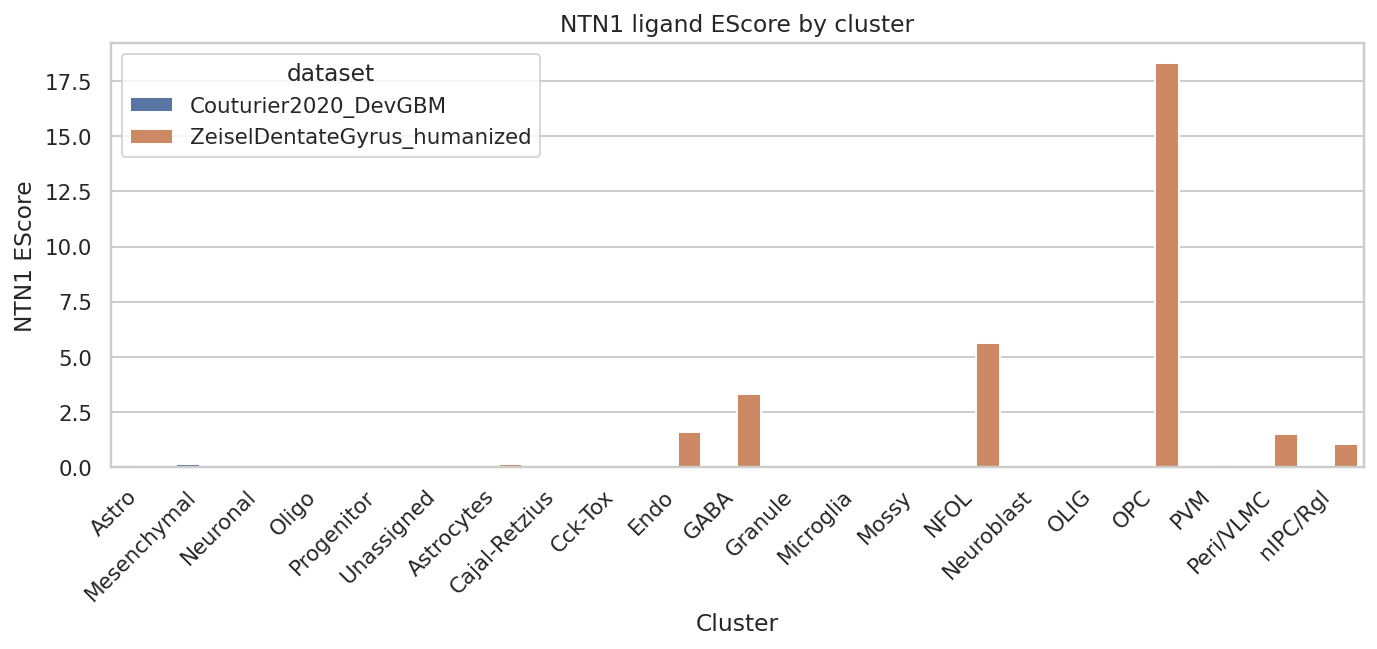

/tmp/ipykernel_44282/3467471510.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [8]:
# NOTE: This cell belongs to the tutorial step above. Run it after reading that section note.
ntn1_plot_df = (
    ntn1_escore.reset_index()
    .rename(columns={"index": "cluster"})
    .melt(id_vars="cluster", var_name="dataset", value_name="NTN1_EScore")
)

plt.figure(figsize=(10, 4.8))
sns.barplot(data=ntn1_plot_df, x="cluster", y="NTN1_EScore", hue="dataset")
plt.xticks(rotation=45, ha="right")
plt.title("NTN1 ligand EScore by cluster")
plt.xlabel("Cluster")
plt.ylabel("NTN1 EScore")
plt.tight_layout()
save_current_fig("fig1_ntn1_ligand_escore_by_cluster.png")
plt.show()

## Step 8 - Figure 2: Cluster-Level NTN1 Communication Summary

> **Note:** These heatmaps aggregate all NTN1 receptor-pair scores for each source-target cluster pair.

Saved figure: /mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260605/outputs/ntn1_couturier_zeisel_pypi047b0_tutorial/figures/fig2a_ntn1_couturier_to_zeisel_cluster_heatmap.png


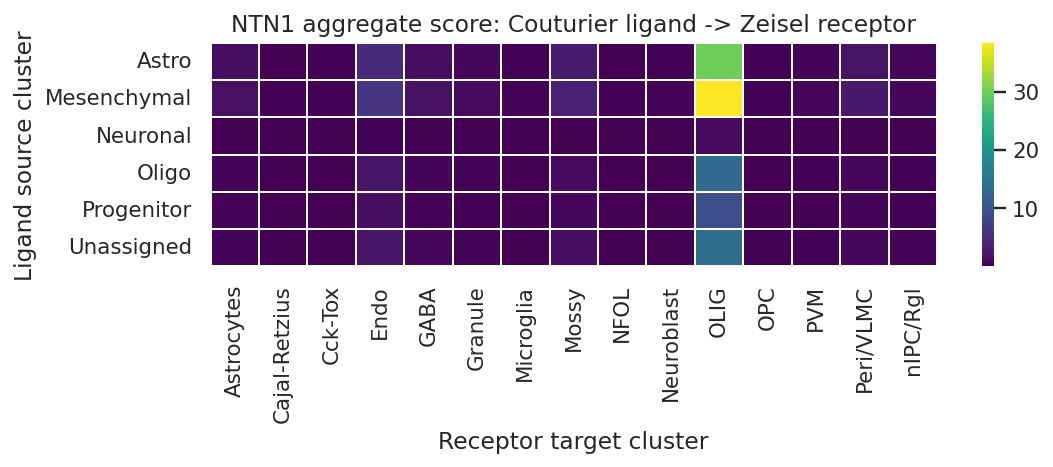

/tmp/ipykernel_44282/1613348558.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


Saved figure: /mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260605/outputs/ntn1_couturier_zeisel_pypi047b0_tutorial/figures/fig2b_ntn1_zeisel_to_couturier_cluster_heatmap.png


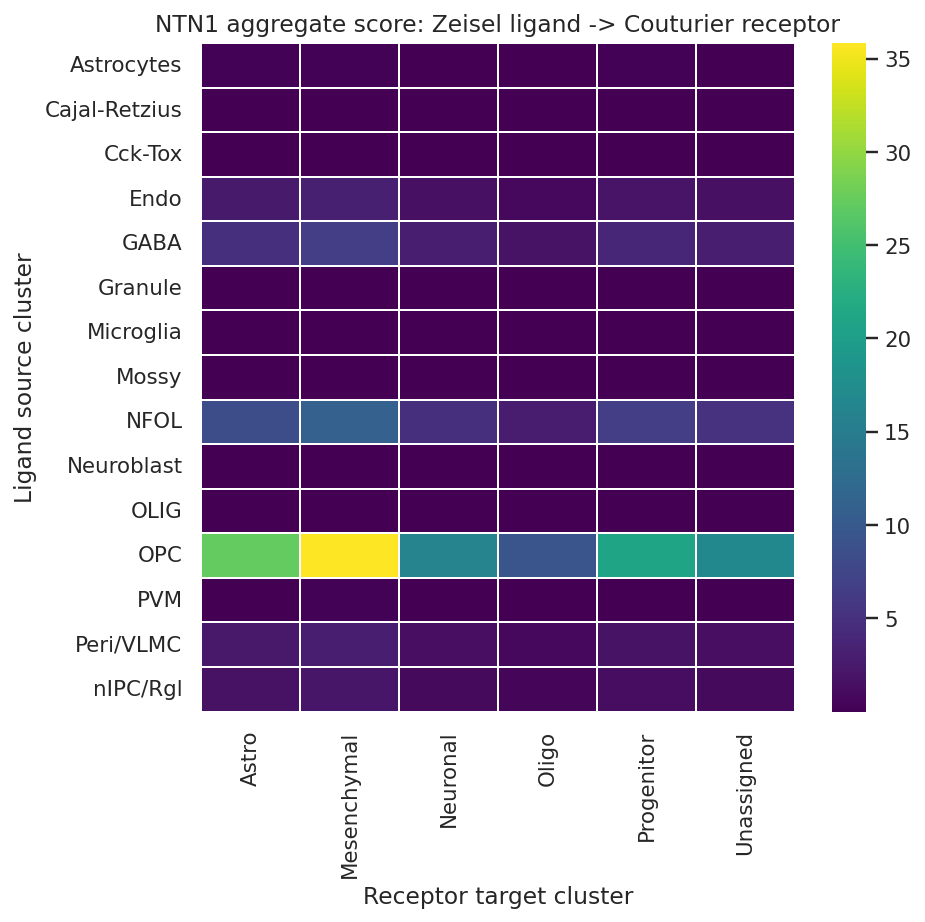

Saved table: /mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260605/outputs/ntn1_couturier_zeisel_pypi047b0_tutorial/tables/ntn1_couturier_to_zeisel_cluster_heatmap_matrix.csv
Saved table: /mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260605/outputs/ntn1_couturier_zeisel_pypi047b0_tutorial/tables/ntn1_zeisel_to_couturier_cluster_heatmap_matrix.csv


/tmp/ipykernel_44282/1613348558.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


PosixPath('/mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260605/outputs/ntn1_couturier_zeisel_pypi047b0_tutorial/tables/ntn1_zeisel_to_couturier_cluster_heatmap_matrix.csv')

In [9]:
# NOTE: This cell belongs to the tutorial step above. Run it after reading that section note.
def cluster_heatmap(direction_label, title, filename):
    data = cluster_pair_summary.loc[cluster_pair_summary["direction"] == direction_label]
    mat = data.pivot_table(
        index="source_cluster",
        columns="target_cluster",
        values="score",
        aggfunc="sum",
        fill_value=0,
        observed=False,
    )
    plt.figure(figsize=(max(7, mat.shape[1] * 0.55), max(3.5, mat.shape[0] * 0.45)))
    sns.heatmap(mat, cmap="viridis", linewidths=0.2, linecolor="white")
    plt.title(title)
    plt.xlabel("Receptor target cluster")
    plt.ylabel("Ligand source cluster")
    plt.tight_layout()
    save_current_fig(filename)
    plt.show()
    return mat


main_to_zeisel_cluster_mat = cluster_heatmap(
    "Couturier2020_DevGBM -> ZeiselDentateGyrus_humanized",
    "NTN1 aggregate score: Couturier ligand -> Zeisel receptor",
    "fig2a_ntn1_couturier_to_zeisel_cluster_heatmap.png",
)
zeisel_to_main_cluster_mat = cluster_heatmap(
    "ZeiselDentateGyrus_humanized -> Couturier2020_DevGBM",
    "NTN1 aggregate score: Zeisel ligand -> Couturier receptor",
    "fig2b_ntn1_zeisel_to_couturier_cluster_heatmap.png",
)

save_table(main_to_zeisel_cluster_mat, "ntn1_couturier_to_zeisel_cluster_heatmap_matrix.csv")
save_table(zeisel_to_main_cluster_mat, "ntn1_zeisel_to_couturier_cluster_heatmap_matrix.csv")

## Step 9 - Figure 3: Receptor-Level NTN1 Scores

> **Note:** These heatmaps show which NTN1 receptors drive the strongest target-cluster signals.

Saved figure: /mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260605/outputs/ntn1_couturier_zeisel_pypi047b0_tutorial/figures/fig3a_ntn1_receptor_scores_zeisel_targets.png


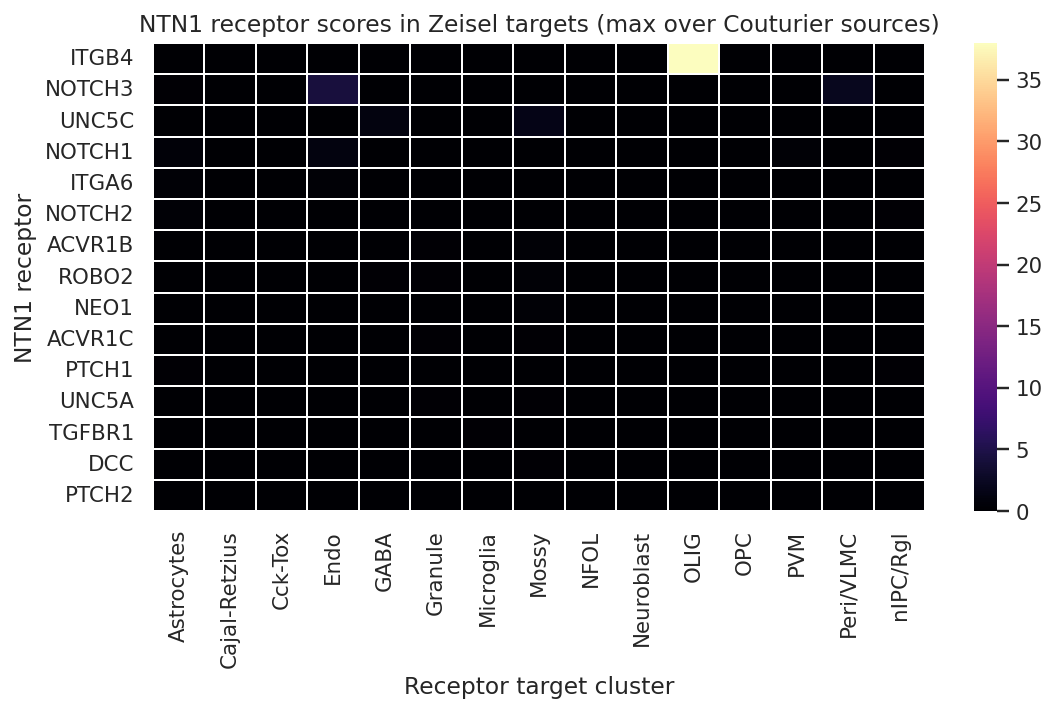

/tmp/ipykernel_44282/2788169585.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


Saved figure: /mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260605/outputs/ntn1_couturier_zeisel_pypi047b0_tutorial/figures/fig3b_ntn1_receptor_scores_couturier_targets.png


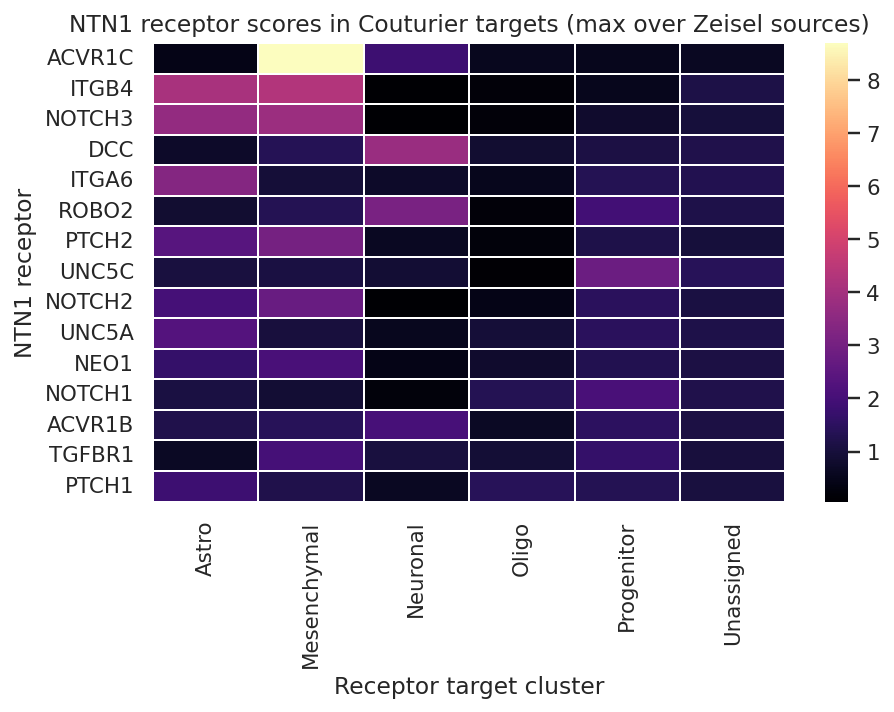

Saved table: /mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260605/outputs/ntn1_couturier_zeisel_pypi047b0_tutorial/tables/ntn1_receptor_scores_zeisel_targets.csv
Saved table: /mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260605/outputs/ntn1_couturier_zeisel_pypi047b0_tutorial/tables/ntn1_receptor_scores_couturier_targets.csv


/tmp/ipykernel_44282/2788169585.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


PosixPath('/mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260605/outputs/ntn1_couturier_zeisel_pypi047b0_tutorial/tables/ntn1_receptor_scores_couturier_targets.csv')

In [10]:
# NOTE: This cell belongs to the tutorial step above. Run it after reading that section note.
def receptor_target_heatmap(direction_label, title, filename):
    data = long_scores.loc[long_scores["direction"] == direction_label]
    mat = data.pivot_table(
        index="receptor",
        columns="target_cluster",
        values="score",
        aggfunc="max",
        fill_value=0,
        observed=False,
    )
    mat = mat.loc[mat.max(axis=1).sort_values(ascending=False).index]
    plt.figure(figsize=(max(7, mat.shape[1] * 0.55), max(4, mat.shape[0] * 0.35)))
    sns.heatmap(mat, cmap="magma", linewidths=0.2, linecolor="white")
    plt.title(title)
    plt.xlabel("Receptor target cluster")
    plt.ylabel("NTN1 receptor")
    plt.tight_layout()
    save_current_fig(filename)
    plt.show()
    return mat


main_to_zeisel_receptor_mat = receptor_target_heatmap(
    "Couturier2020_DevGBM -> ZeiselDentateGyrus_humanized",
    "NTN1 receptor scores in Zeisel targets (max over Couturier sources)",
    "fig3a_ntn1_receptor_scores_zeisel_targets.png",
)
zeisel_to_main_receptor_mat = receptor_target_heatmap(
    "ZeiselDentateGyrus_humanized -> Couturier2020_DevGBM",
    "NTN1 receptor scores in Couturier targets (max over Zeisel sources)",
    "fig3b_ntn1_receptor_scores_couturier_targets.png",
)

save_table(main_to_zeisel_receptor_mat, "ntn1_receptor_scores_zeisel_targets.csv")
save_table(zeisel_to_main_receptor_mat, "ntn1_receptor_scores_couturier_targets.csv")

## Step 10 - Figure 4: Top Directional NTN1 Interactions

> **Note:** This ranked bar plot shows the strongest individual ligand-receptor/cluster combinations across both directions. The readable version shortens dataset names, wraps each interaction label onto two lines, places value labels at the end of each bar, and moves the legend below the chart.


Saved figure: /mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260605/outputs/ntn1_couturier_zeisel_pypi047b0_tutorial/figures/fig4_top_ntn1_directional_interactions_readable.png


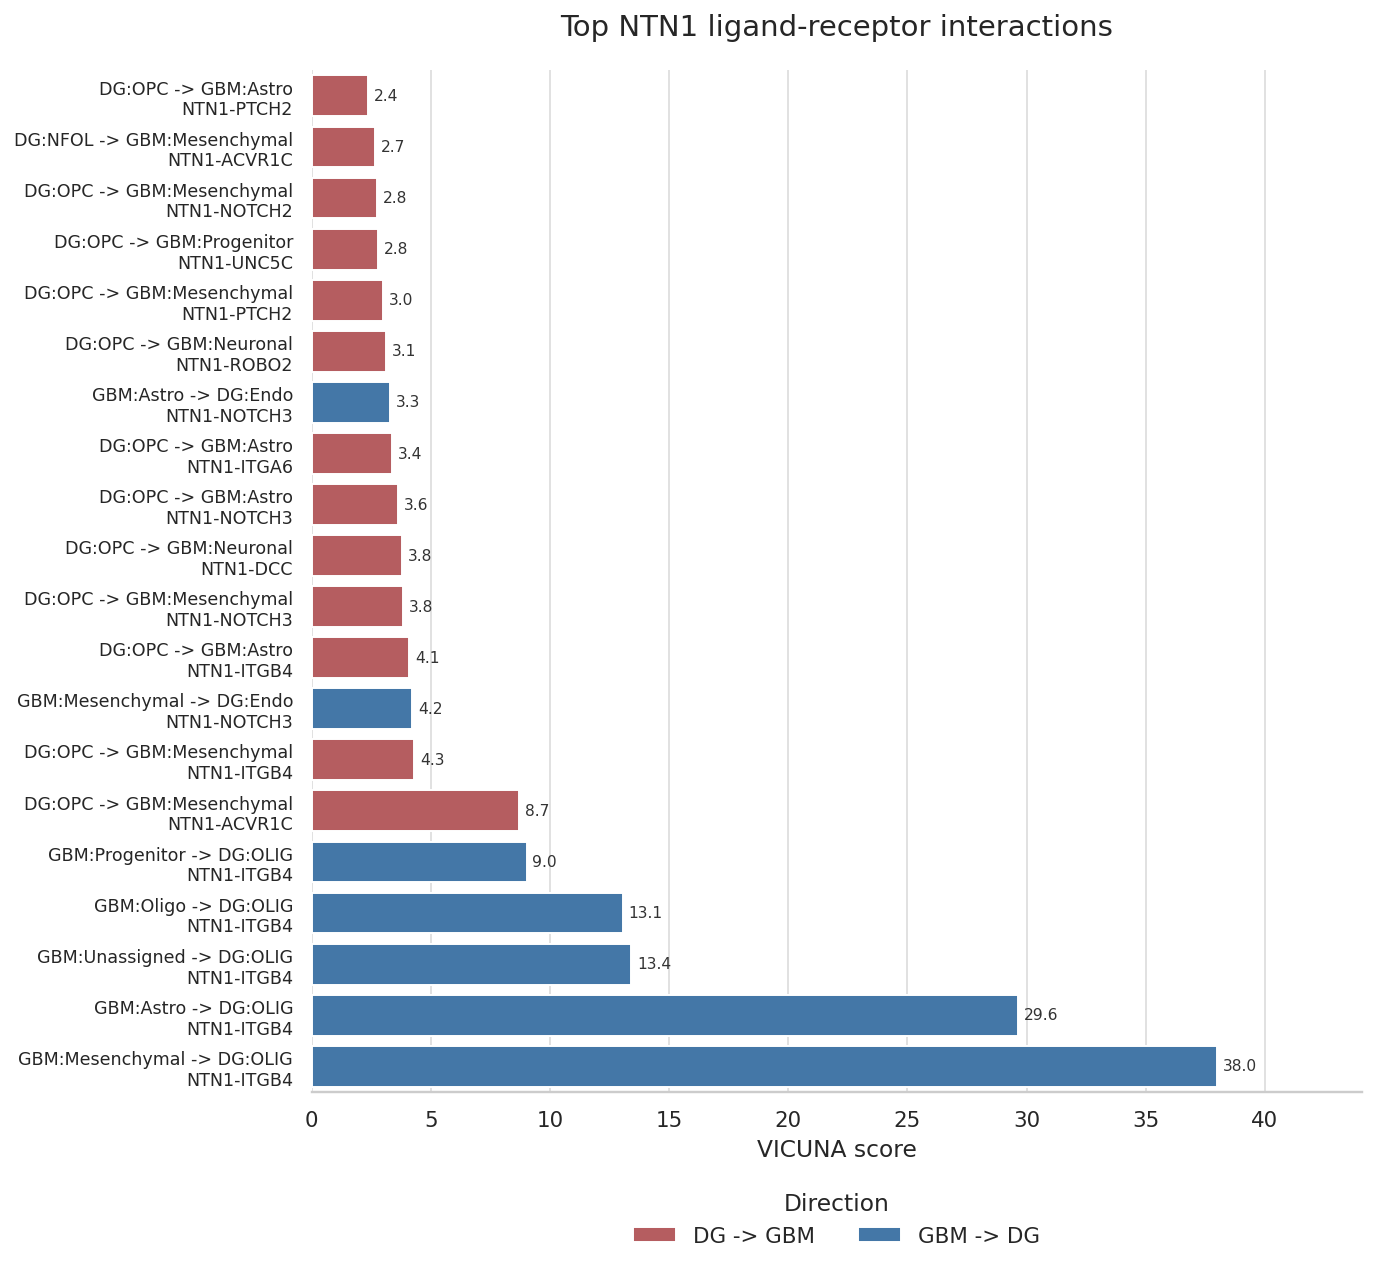

/tmp/ipykernel_44282/3532936759.py:55: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [11]:
# NOTE: This readable Figure 4 version wraps long interaction labels and moves the legend outside the bars.
top_plot = top_interactions.copy().head(20).copy()
dataset_short = {
    "Couturier2020_DevGBM": "GBM",
    "ZeiselDentateGyrus_humanized": "DG",
}
top_plot["direction_short"] = top_plot["direction"].map(_short_direction_name)
top_plot["interaction_label"] = top_plot.apply(
    lambda r: (
        f"{dataset_short.get(r['source_dataset'], r['source_dataset'])}:{r['source_cluster']}"
        f" -> {dataset_short.get(r['target_dataset'], r['target_dataset'])}:{r['target_cluster']}\n"
        f"{r['pair']}"
    ),
    axis=1,
)
top_plot = top_plot.sort_values("score", ascending=True)

fig_height = max(7.0, len(top_plot) * 0.48)
fig, ax = plt.subplots(figsize=(12.5, fig_height))
palette = {"GBM -> DG": "#3478b7", "DG -> GBM": "#c44e52"}
sns.barplot(
    data=top_plot,
    y="interaction_label",
    x="score",
    hue="direction_short",
    dodge=False,
    palette=palette,
    ax=ax,
)
ax.set_title("Top NTN1 ligand-receptor interactions", pad=18, fontsize=15)
ax.set_xlabel("VICUNA score")
ax.set_ylabel("")
ax.tick_params(axis="y", labelsize=9)
ax.grid(axis="x", color="#d9d9d9", linewidth=0.8)
ax.grid(axis="y", visible=False)

max_score = float(top_plot["score"].max())
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3, fontsize=8, color="#333333")
ax.set_xlim(0, max_score * 1.16)

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles,
    labels,
    title="Direction",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=2,
    frameon=False,
)
sns.despine(ax=ax, left=True)
fig.subplots_adjust(left=0.36, right=0.96, top=0.92, bottom=0.16)
save_current_fig("fig4_top_ntn1_directional_interactions_readable.png")
plt.show()


## Step 11 - Figure 5: Chord-Style NTN1 Cluster Communication Plot

> **Note:** The chord-style plot summarizes the strongest aggregate cluster-to-cluster NTN1 communication paths. Node size reflects total score among the displayed edges, and edge width reflects aggregate VICUNA score. The readable version uses fewer top edges and reserves separate canvas space for the title, labels, and legend.


Saved figure: /mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260605/outputs/ntn1_couturier_zeisel_pypi047b0_tutorial/figures/fig5_ntn1_chord_cluster_communication_readable.png


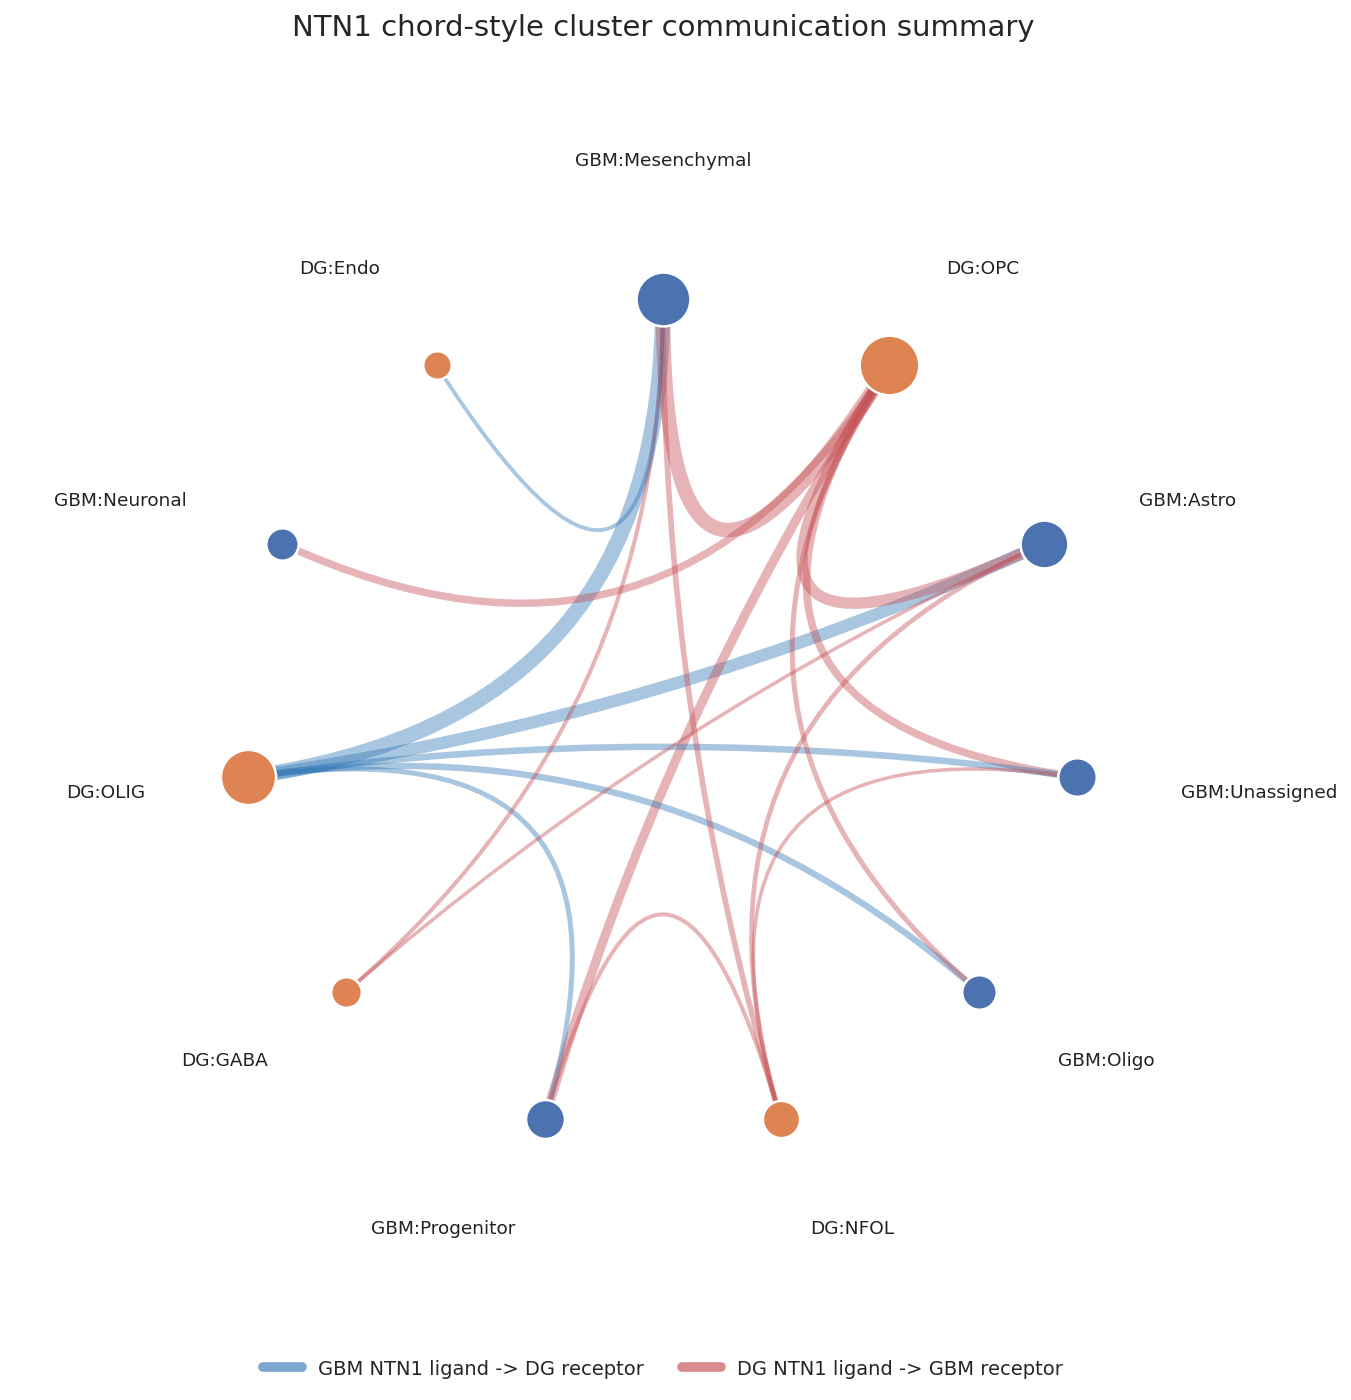

,direction,direction_short,source_node,target_node,score
2,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,GBM -> DG,GBM:Mesenchymal,DG:OLIG,38.356154
13,ZeiselDentateGyrus_humanized -> Couturier2020_...,DG -> GBM,DG:OPC,GBM:Mesenchymal,35.835365
0,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,GBM -> DG,GBM:Astro,DG:OLIG,29.938549
12,ZeiselDentateGyrus_humanized -> Couturier2020_...,DG -> GBM,DG:OPC,GBM:Astro,27.216096
16,ZeiselDentateGyrus_humanized -> Couturier2020_...,DG -> GBM,DG:OPC,GBM:Progenitor,20.990887
17,ZeiselDentateGyrus_humanized -> Couturier2020_...,DG -> GBM,DG:OPC,GBM:Unassigned,16.663185
14,ZeiselDentateGyrus_humanized -> Couturier2020_...,DG -> GBM,DG:OPC,GBM:Neuronal,16.112459
5,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,GBM -> DG,GBM:Unassigned,DG:OLIG,13.540250
3,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,GBM -> DG,GBM:Oligo,DG:OLIG,13.181904
9,ZeiselDentateGyrus_humanized -> Couturier2020_...,DG -> GBM,DG:NFOL,GBM:Mesenchymal,11.018728


Saved table: /mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260605/outputs/ntn1_couturier_zeisel_pypi047b0_tutorial/tables/ntn1_chord_edges_top_cluster_pairs_readable.csv


/tmp/ipykernel_44282/950928336.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [12]:
# NOTE: Build a compact chord-style summary using the strongest cluster-pair scores.
# NOTE: The helper keeps the legend below the circle and places labels farther from the nodes.
chord_edges, chord_path = draw_chord_plot(
    cluster_pair_summary,
    filename="fig5_ntn1_chord_cluster_communication_readable.png",
    top_n=18,
    title="NTN1 chord-style cluster communication summary",
)
display(chord_edges)
save_table(chord_edges, "ntn1_chord_edges_top_cluster_pairs_readable.csv")
plt.show()


## Step 12 - Figure 6: Sankey/Alluvial Plot For Top NTN1 Paths

> **Note:** The Sankey/alluvial plot traces the top individual NTN1 paths from source cluster to receptor gene to target cluster. This view is useful for teaching which receptors drive the highest-ranked interactions, and the helper now leaves extra margin for side labels and the direction legend.


Saved figure: /mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260605/outputs/ntn1_couturier_zeisel_pypi047b0_tutorial/figures/fig6_ntn1_sankey_top_paths_readable.png


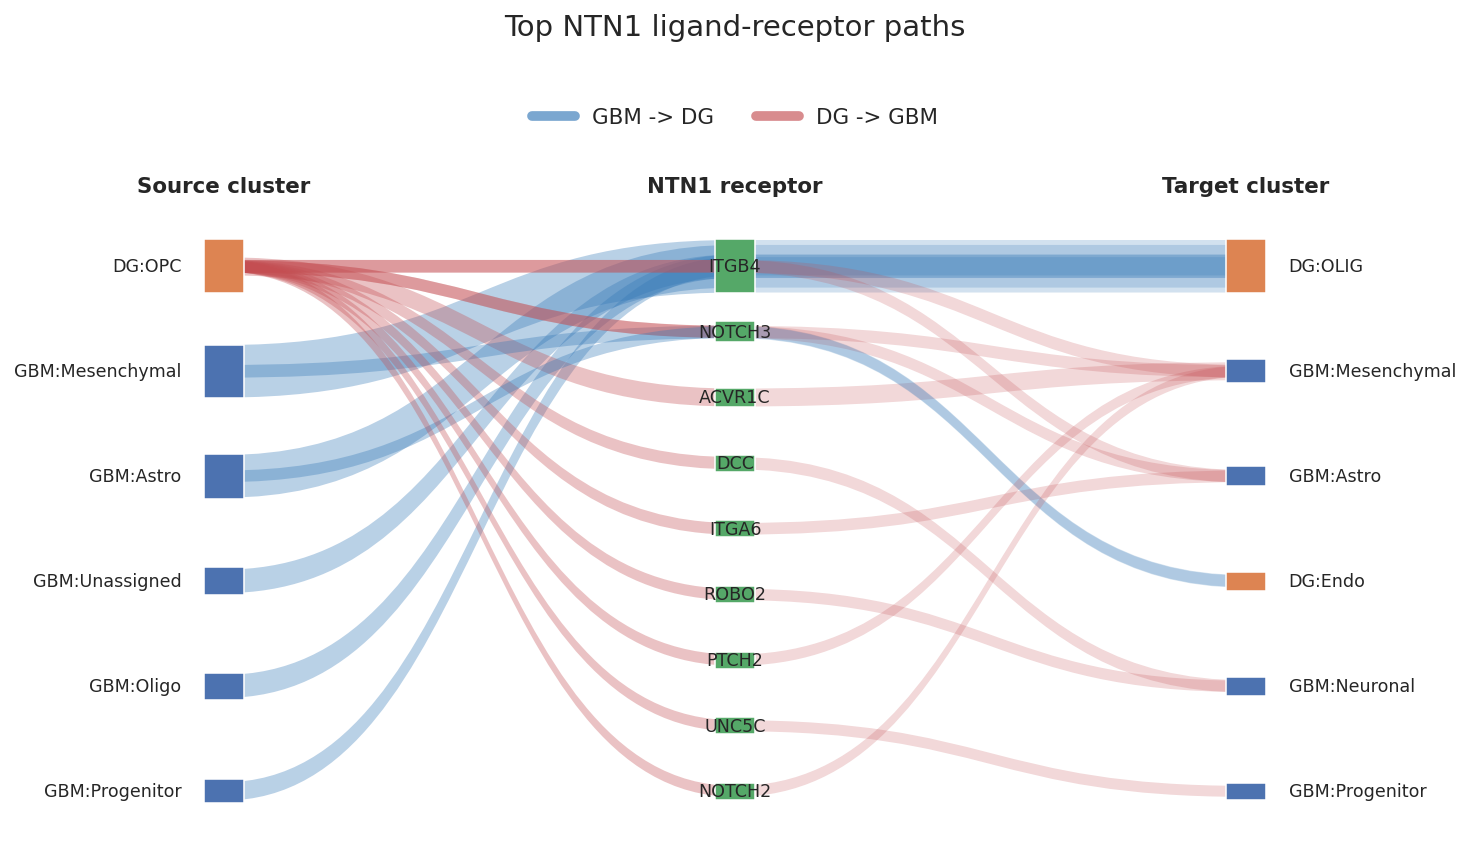

,direction,source_dataset,target_dataset,source_cluster,target_cluster,pair,ligand,receptor,score,source_node,target_node,receptor_node,direction_short
295,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,Couturier2020_DevGBM,ZeiselDentateGyrus_humanized,Mesenchymal,OLIG,NTN1-ITGB4,NTN1,ITGB4,37.977537,GBM:Mesenchymal,DG:OLIG,ITGB4,GBM -> DG
280,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,Couturier2020_DevGBM,ZeiselDentateGyrus_humanized,Astro,OLIG,NTN1-ITGB4,NTN1,ITGB4,29.643023,GBM:Astro,DG:OLIG,ITGB4,GBM -> DG
355,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,Couturier2020_DevGBM,ZeiselDentateGyrus_humanized,Unassigned,OLIG,NTN1-ITGB4,NTN1,ITGB4,13.406593,GBM:Unassigned,DG:OLIG,ITGB4,GBM -> DG
325,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,Couturier2020_DevGBM,ZeiselDentateGyrus_humanized,Oligo,OLIG,NTN1-ITGB4,NTN1,ITGB4,13.051785,GBM:Oligo,DG:OLIG,ITGB4,GBM -> DG
340,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,Couturier2020_DevGBM,ZeiselDentateGyrus_humanized,Progenitor,OLIG,NTN1-ITGB4,NTN1,ITGB4,9.019840,GBM:Progenitor,DG:OLIG,ITGB4,GBM -> DG
2407,ZeiselDentateGyrus_humanized -> Couturier2020_...,ZeiselDentateGyrus_humanized,Couturier2020_DevGBM,OPC,Mesenchymal,NTN1-ACVR1C,NTN1,ACVR1C,8.698030,DG:OPC,GBM:Mesenchymal,ACVR1C,DG -> GBM
1687,ZeiselDentateGyrus_humanized -> Couturier2020_...,ZeiselDentateGyrus_humanized,Couturier2020_DevGBM,OPC,Mesenchymal,NTN1-ITGB4,NTN1,ITGB4,4.295583,DG:OPC,GBM:Mesenchymal,ITGB4,DG -> GBM
1188,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,Couturier2020_DevGBM,ZeiselDentateGyrus_humanized,Mesenchymal,Endo,NTN1-NOTCH3,NTN1,NOTCH3,4.228401,GBM:Mesenchymal,DG:Endo,NOTCH3,GBM -> DG
1686,ZeiselDentateGyrus_humanized -> Couturier2020_...,ZeiselDentateGyrus_humanized,Couturier2020_DevGBM,OPC,Astro,NTN1-ITGB4,NTN1,ITGB4,4.090730,DG:OPC,GBM:Astro,ITGB4,DG -> GBM
2587,ZeiselDentateGyrus_humanized -> Couturier2020_...,ZeiselDentateGyrus_humanized,Couturier2020_DevGBM,OPC,Mesenchymal,NTN1-NOTCH3,NTN1,NOTCH3,3.827139,DG:OPC,GBM:Mesenchymal,NOTCH3,DG -> GBM


Saved table: /mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260605/outputs/ntn1_couturier_zeisel_pypi047b0_tutorial/tables/ntn1_sankey_top_flows_readable.csv


/tmp/ipykernel_44282/234063455.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [13]:
# NOTE: Draw the top individual NTN1 paths as source cluster -> receptor -> target cluster.
sankey_flows, sankey_path = draw_sankey_alluvial(
    top_interactions,
    filename="fig6_ntn1_sankey_top_paths_readable.png",
    top_n=18,
    title="Top NTN1 ligand-receptor paths",
)
display(sankey_flows)
save_table(sankey_flows, "ntn1_sankey_top_flows_readable.csv")
plt.show()


## Step 13 - Key Tables

> **Note:** These displayed tables are the main tutorial outputs to inspect interactively after reviewing the figures.

In [14]:
# NOTE: This cell belongs to the tutorial step above. Run it after reading that section note.
print("Top 20 interactions")
display(top_interactions.head(20))

print("Available NTN1 receptor pairs")
display(ntn1_pairs)

print("Cluster-pair summary")
display(cluster_pair_summary.head(30))

Top 20 interactions


,direction,source_dataset,target_dataset,source_cluster,target_cluster,pair,ligand,receptor,score
295,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,Couturier2020_DevGBM,ZeiselDentateGyrus_humanized,Mesenchymal,OLIG,NTN1-ITGB4,NTN1,ITGB4,37.977537
280,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,Couturier2020_DevGBM,ZeiselDentateGyrus_humanized,Astro,OLIG,NTN1-ITGB4,NTN1,ITGB4,29.643023
355,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,Couturier2020_DevGBM,ZeiselDentateGyrus_humanized,Unassigned,OLIG,NTN1-ITGB4,NTN1,ITGB4,13.406593
325,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,Couturier2020_DevGBM,ZeiselDentateGyrus_humanized,Oligo,OLIG,NTN1-ITGB4,NTN1,ITGB4,13.051785
340,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,Couturier2020_DevGBM,ZeiselDentateGyrus_humanized,Progenitor,OLIG,NTN1-ITGB4,NTN1,ITGB4,9.019840
2407,ZeiselDentateGyrus_humanized -> Couturier2020_...,ZeiselDentateGyrus_humanized,Couturier2020_DevGBM,OPC,Mesenchymal,NTN1-ACVR1C,NTN1,ACVR1C,8.698030
1687,ZeiselDentateGyrus_humanized -> Couturier2020_...,ZeiselDentateGyrus_humanized,Couturier2020_DevGBM,OPC,Mesenchymal,NTN1-ITGB4,NTN1,ITGB4,4.295583
1188,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,Couturier2020_DevGBM,ZeiselDentateGyrus_humanized,Mesenchymal,Endo,NTN1-NOTCH3,NTN1,NOTCH3,4.228401
1686,ZeiselDentateGyrus_humanized -> Couturier2020_...,ZeiselDentateGyrus_humanized,Couturier2020_DevGBM,OPC,Astro,NTN1-ITGB4,NTN1,ITGB4,4.090730
2587,ZeiselDentateGyrus_humanized -> Couturier2020_...,ZeiselDentateGyrus_humanized,Couturier2020_DevGBM,OPC,Mesenchymal,NTN1-NOTCH3,NTN1,NOTCH3,3.827139


Available NTN1 receptor pairs


,PPI,ligand_symbol,receptor_symbol,receptor_in_couturier,receptor_in_zeisel_humanized,ligand_in_couturier,ligand_in_zeisel_humanized
NTN1-DCC,NTN1_DCC,NTN1,DCC,True,True,True,True
NTN1-UNC5C,NTN1_UNC5C,NTN1,UNC5C,True,True,True,True
NTN1-NEO1,NTN1_NEO1,NTN1,NEO1,True,True,True,True
NTN1-ITGB4,NTN1_ITGB4,NTN1,ITGB4,True,True,True,True
NTN1-ITGA6,NTN1_ITGA6,NTN1,ITGA6,True,True,True,True
NTN1-ACVR1B,NTN1_ACVR1B,NTN1,ACVR1B,True,True,True,True
NTN1-TGFBR1,NTN1_TGFBR1,NTN1,TGFBR1,True,True,True,True
NTN1-NOTCH1,NTN1_NOTCH1,NTN1,NOTCH1,True,True,True,True
NTN1-NOTCH2,NTN1_NOTCH2,NTN1,NOTCH2,True,True,True,True
NTN1-PTCH1,NTN1_PTCH1,NTN1,PTCH1,True,True,True,True


Cluster-pair summary


,direction,source_cluster,target_cluster,score
25,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,Mesenchymal,OLIG,38.356154
157,ZeiselDentateGyrus_humanized -> Couturier2020_...,OPC,Mesenchymal,35.835365
10,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,Astro,OLIG,29.938549
156,ZeiselDentateGyrus_humanized -> Couturier2020_...,OPC,Astro,27.216096
160,ZeiselDentateGyrus_humanized -> Couturier2020_...,OPC,Progenitor,20.990887
161,ZeiselDentateGyrus_humanized -> Couturier2020_...,OPC,Unassigned,16.663185
158,ZeiselDentateGyrus_humanized -> Couturier2020_...,OPC,Neuronal,16.112459
85,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,Unassigned,OLIG,13.540250
55,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,Oligo,OLIG,13.181904
139,ZeiselDentateGyrus_humanized -> Couturier2020_...,NFOL,Mesenchymal,11.018728


## Output Files

The notebook saves CSV tables under `outputs/ntn1_couturier_zeisel_pypi047b0_tutorial/tables`
and figures under `outputs/ntn1_couturier_zeisel_pypi047b0_tutorial/figures`.


In [15]:
# NOTE: This cell belongs to the tutorial step above. Run it after reading that section note.
print("Tables:")
for path in sorted(TABLE_DIR.glob("*.csv")):
    print(" -", path)

print("\nFigures:")
for path in sorted(FIG_DIR.glob("*.png")):
    print(" -", path)

Tables:
 - /mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260605/outputs/ntn1_couturier_zeisel_pypi047b0_tutorial/tables/cluster_counts.csv
 - /mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260605/outputs/ntn1_couturier_zeisel_pypi047b0_tutorial/tables/couturier_escore_genes_by_cluster.csv
 - /mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260605/outputs/ntn1_couturier_zeisel_pypi047b0_tutorial/tables/dataset_summary.csv
 - /mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260605/outputs/ntn1_couturier_zeisel_pypi047b0_tutorial/tables/ntn1_all_directional_scores_long.csv
 - /mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260605/outputs/ntn1_couturier_zeisel_pypi047b0_tutorial/tables/ntn1_chord_edges_top_cluster_pairs_readable.csv
 - /mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260605/outputs/ntn1_couturier_zeisel_pypi047b0_tutorial/tables/ntn1_cluster_pair_score_summary.csv
 - /mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_update